**Loading Necessary Libraries**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install catboost
from catboost import CatBoostRegressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00


 - **Load Our dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


df = pd.read_csv("/content/drive/MyDrive/supply_chain_thesis/engineered_dataset.csv")
df.head()


Mounted at /content/drive


,Date,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,...,Supplier_ID_SUP_3,Supplier_ID_SUP_4,Supplier_ID_SUP_5,Supplier_ID_SUP_6,Supplier_ID_SUP_7,Supplier_ID_SUP_8,Supplier_ID_SUP_9,Region_North,Region_South,Region_West
0,2024-01-01,28,719,8,208,0,17.86,27.62,0,0,...,0,1,0,0,0,0,0,0,1,0
1,2024-01-01,20,692,3,249,0,18.62,32.27,0,0,...,0,0,0,0,0,1,0,1,0,0
2,2024-01-01,18,741,4,299,0,9.01,16.16,0,0,...,1,0,0,0,0,0,0,0,1,0
3,2024-01-01,26,735,5,248,0,9.10,15.43,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2024-01-01,19,642,13,260,0,5.63,8.49,1,0,...,0,0,1,0,0,0,0,1,0,0


- **Target and Feature Variables**

In [ ]:
X = df.drop(['Units_Sold', 'Date'], axis=1)
y = df['Units_Sold']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

**Scale the features**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**MLP base line model**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X_train_scaled.shape[1]

model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

- **Training the MLP baseline Model**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[es],
    verbose=1
)


Epoch 1/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 156.5493 - mae: 9.0455 - val_loss: 26.8172 - val_mae: 4.1899
Epoch 2/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 13.5138 - mae: 2.9175 - val_loss: 17.8975 - val_mae: 3.4172
Epoch 3/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.4892 - mae: 2.3174 - val_loss: 12.8862 - val_mae: 2.8890
Epoch 4/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.2975 - mae: 2.1509 - val_loss: 9.4582 - val_mae: 2.4685
Epoch 5/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.7926 - mae: 2.0761 - val_loss: 7.8207 - val_mae: 2.2441
Epoch 6/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.4728 - mae: 2.0273 - val_loss: 7.1758 - val_mae: 2.1507
Epoch 7/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2702 - mae: 1.9958 - val_loss: 6.8765 - val_mae: 2.1063
Epoch 8/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1070 - mae: 1.9697 - val_loss: 6.9262 - val_mae: 2.1143
Epoch 9/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

- **Evaluate the MLP baseline Model**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = model.predict(X_test_scaled).ravel()

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)

print("MLP Test RMSE:", rmse)
print("MLP Test MAE:", mae)


571/571 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
MLP Test RMSE: 2.4434102127067847
MLP Test MAE: 1.9286563396453857


**Build the GRU sequence dataset**

In [ ]:
import numpy as np

def create_sequences(X, y, window=30):
    X_seq, y_seq = [], []
    for i in range(window, len(X)):
        X_seq.append(X[i-window:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

window_size = 30

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, window_size)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, window_size)

X_train_seq.shape, X_test_seq.shape

((72946, 30, 91), (18214, 30, 91))

**Build the GRU model**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

timesteps = X_train_seq.shape[1]
num_features = X_train_seq.shape[2]

model_gru = models.Sequential([
    layers.GRU(64, return_sequences=True, input_shape=(timesteps, num_features)),
    layers.GRU(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model_gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model_gru.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        30,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,097 (156.63 KB)

 Trainable params: 40,097 (156.63 KB)

 Non-trainable params: 0 (0.00 B)

**Train the GRU model**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_gru = model_gru.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=[es],
    verbose=1
)


Epoch 1/40
912/912 ━━━━━━━━━━━━━━━━━━━━ 53s 52ms/step - loss: 77.4356 - mae: 6.3669 - val_loss: 27.0374 - val_mae: 4.1815
Epoch 2/40
912/912 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - loss: 31.7059 - mae: 4.4132 - val_loss: 27.4450 - val_mae: 4.1966
Epoch 3/40
912/912 ━━━━━━━━━━━━━━━━━━━━ 83s 50ms/step - loss: 31.4874 - mae: 4.3959 - val_loss: 28.6474 - val_mae: 4.3131
Epoch 4/40
912/912 ━━━━━━━━━━━━━━━━━━━━ 48s 53ms/step - loss: 31.2846 - mae: 4.3820 - val_loss: 37.8112 - val_mae: 4.8594
Epoch 5/40
912/912 ━━━━━━━━━━━━━━━━━━━━ 45s 50ms/step - loss: 31.0570 - mae: 4.3669 - val_loss: 27.6444 - val_mae: 4.2237
Epoch 6/40
912/912 ━━━━━━━━━━━━━━━━━━━━ 45s 50ms/step - loss: 30.7092 - mae: 4.3429 - val_loss: 28.7435 - val_mae: 4.2985


- **Evaluate the GRU model**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred_gru = model_gru.predict(X_test_seq).ravel()

mse = mean_squared_error(y_test_seq, y_pred_gru)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test_seq, y_pred_gru)

print("GRU Test RMSE:", rmse)
print("GRU Test MAE:", mae)


570/570 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step
GRU Test RMSE: 5.879189803170095
GRU Test MAE: 4.637609004974365


we observe from the evaluation the GRU model performs very badly

In [ ]:
!pip install pytorch-tabnet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.4 MB/s eta 0:00:00


**Build the TabNetRegressor**

In [ ]:
from pytorch_tabnet.tab_model import TabNetRegressor
import torch

tabnet_model = TabNetRegressor(
    n_d=32,       # width of decision prediction layer
    n_a=32,       # width of attention layer
    n_steps=5,    # number of decision steps
    gamma=1.5,    # relaxation parameter
    n_independent=2,
    n_shared=2,
    momentum=0.02,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-3),
    mask_type='entmax'  # sparse attention
)


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


**Train TabNet**

In [ ]:
X_train_tab = X_train_scaled.astype(np.float32)
y_train_tab = y_train.values.astype(np.float32)
X_test_tab = X_test_scaled.astype(np.float32)
y_test_tab = y_test.values.astype(np.float32)

tabnet_model.fit(
    X_train=X_train_tab,
    y_train=y_train_tab.reshape(-1, 1),
    eval_set=[(X_test_tab, y_test_tab.reshape(-1, 1))],
    eval_metric=['rmse'],
    max_epochs=100,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

epoch 0  | loss: 394.65321| val_0_rmse: 11.63017|  0:00:21s
epoch 1  | loss: 235.06884| val_0_rmse: 8.96925 |  0:00:36s
epoch 2  | loss: 113.54815| val_0_rmse: 7.11703 |  0:00:52s
epoch 3  | loss: 52.42987| val_0_rmse: 6.23524 |  0:01:07s
epoch 4  | loss: 30.62067| val_0_rmse: 5.14443 |  0:01:22s
epoch 5  | loss: 21.5106 | val_0_rmse: 4.52275 |  0:01:42s
epoch 6  | loss: 17.51106| val_0_rmse: 4.07758 |  0:01:58s
epoch 7  | loss: 14.45992| val_0_rmse: 3.65779 |  0:02:15s
epoch 8  | loss: 12.37048| val_0_rmse: 3.32859 |  0:02:30s
epoch 9  | loss: 10.9819 | val_0_rmse: 3.21947 |  0:02:45s
epoch 10 | loss: 10.438  | val_0_rmse: 3.05807 |  0:03:00s
epoch 11 | loss: 9.88077 | val_0_rmse: 3.12104 |  0:03:16s
epoch 12 | loss: 9.4341  | val_0_rmse: 2.91865 |  0:03:32s
epoch 13 | loss: 9.02251 | val_0_rmse: 2.84466 |  0:03:47s
epoch 14 | loss: 8.67183 | val_0_rmse: 2.82836 |  0:04:02s
epoch 15 | loss: 8.58824 | val_0_rmse: 2.80995 |  0:04:17s
epoch 16 | loss: 8.55    | val_0_rmse: 2.77133 |  0:0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Evaluate TabNet

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred_tab = tabnet_model.predict(X_test_tab).ravel()

rmse = mean_squared_error(y_test_tab, y_pred_tab) ** 0.5
mae = mean_absolute_error(y_test_tab, y_pred_tab)

print("TabNet Test RMSE:", rmse)
print("TabNet Test MAE:", mae)

TabNet Test RMSE: 2.425360454237121
TabNet Test MAE: 1.9312676191329956


**Extract TabNet feature importance**

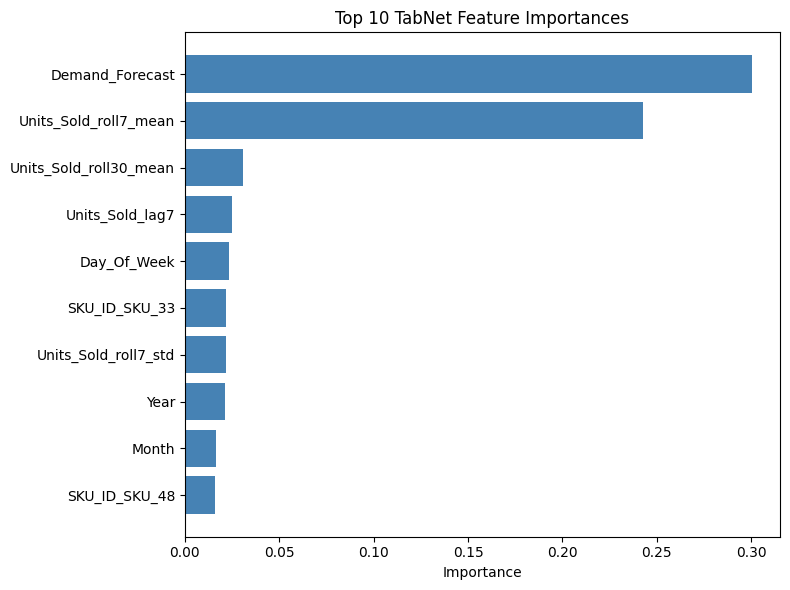

In [ ]:
target_col = "Units_Sold"

# Get feature importances from TabNet
importances = tabnet_model.feature_importances_

# Get feature names
feature_cols = X.columns

# Convert to array for sorting
importances = np.array(importances)

# Sort and select top 10
top_n = 10
indices = np.argsort(importances)[-top_n:]  # last 10 = highest
top_features = np.array(feature_cols)[indices]
top_importances = importances[indices]

# Sort again for nicer plotting
sorted_idx = np.argsort(top_importances)
top_features = top_features[sorted_idx]
top_importances = top_importances[sorted_idx]

# Plot
plt.figure(figsize=(8, 6))
plt.barh(top_features, top_importances, color="steelblue")
plt.title("Top 10 TabNet Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

This plot shows the 10 most influential features that TabNet relied on when predicting demand.
Because TabNet uses sparse attention, it actively selects which features matter most at each decision step. **bold text**